# DFT+U: making an insulator out of a wrongly metallic oxide

LDA and GGA are too comfortable with a localised shell that is partly filled,
which is why they turn an insulating transition-metal oxide into a metal.
Dudarev's correction adds a penalty that is zero at every integer occupation and
positive in between, so the self-consistent field is pushed towards orbitals
that are filled or empty rather than partly both:

$$E_U = \sum_{I,\sigma} \frac{U^I - J^I_0}{2}\,
   \mathrm{Tr}\Big[ n^{I\sigma} \big( 1 - n^{I\sigma} \big) \Big],
\qquad
n^{I\sigma}_{mm'} = \sum_{n\mathbf k} f_{n\mathbf k\sigma}
   \langle \psi_{n\mathbf k\sigma} | \varphi^I_{m'}\rangle
   \langle \varphi^I_{m} | \psi_{n\mathbf k\sigma}\rangle$$

Its potential pushes empty levels up and filled ones down by about $U/2$ each
way, which is the Mott physics the underlying functional is missing. The
potential is the derivative of that energy rather than a second expression
written down beside it.

`U`, `J0`, `alpha` and `beta` come from the `HUBBARD` card, on `atomic`,
`ortho-atomic` or `norm-atomic` projectors. On antiferromagnetic FeO, the
material the correction exists for:

| | defumat | `pw.x` |
|---|---|---|
| total energy, $U = 4.3$ eV | **-174.471560677 Ry** | -174.471560670 |
| total energy, $U \to 0$ | **-174.824657947 Ry** | -174.824657950 |
| seven cases in all | | agree to **6.7e-9 Ry** |
| the Hubbard term itself | | to **4.6e-7 Ry** |
| the Hubbard force | | to **4.8e-6 Ry/bohr** |

The card is written in electronvolts, which is the convention every published
`U` uses, and converted to Rydbergs at the input boundary.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from defumat import Calculator
from defumat.io import comparison_table, read_qe_output

QE = Path("../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite/pw_lda+U")
PSEUDO, REFS = Path("../tests/data/pseudo"), Path("../tests/data/qe")

# The input asks for 1e-6; the agreement being shown is at the 1e-9 the
# reference was generated at.
feo = Calculator.from_file(QE / "lda+U.in", pseudo_dir=PSEUDO, conv_thr=1e-10)
scf = feo.get_scf()

print(f"total energy    {scf.total_energy:.9f} Ry   in {scf.iterations} iterations")
print(f"Hubbard term    {scf.energy_terms['hubbard']:.8f} Ry")

total energy    -174.471560677 Ry   in 48 iterations
Hubbard term    0.31370551 Ry


## The same cell without the correction

Run twice, the two differ only in the `HUBBARD` card. Without `U` the
calculation is the plain LSDA one that gets FeO wrong; with it, the penalty is
doing all the work.

In [2]:
plain = Calculator.from_file(QE / "lda+U-noU.in", pseudo_dir=PSEUDO, conv_thr=1e-10)
no_u = plain.get_scf()

print(comparison_table(
    [("FeO, U = 4.3 eV", scf.total_energy,
      read_qe_output(REFS / "reference.out.pw_lda+U-lda+U").total_energy),
     ("FeO, U -> 0", no_u.total_energy,
      read_qe_output(REFS / "reference.out.pw_lda+U-lda+U-noU").total_energy)],
    fmt="{:.9f}", headers=("total energy [Ry]", "defumat", "pw.x", "difference")))

total energy [Ry]         defumat            pw.x  difference
FeO, U = 4.3 eV    -174.471560677  -174.471560670     6.6e-09
FeO, U -> 0        -174.824657947  -174.824657950     3.4e-09


The $U \to 0$ row is worth as much as the other one. The whole apparatus runs in
it -- the projectors are built, the occupation matrix is accumulated and
symmetrised, the penalty enters the Hamiltonian -- and it has to change nothing.
A correction that is right where it matters and wrong where it should vanish is
the easier of the two mistakes to make.

## What the correction actually does

The eigenvalues of the occupation matrix are the occupations of the *natural*
orbitals of the shell. Without `U` they sit wherever the band structure puts
them; with it they are pushed towards 0 and 1. That is the entire mechanism, and
in FeO it is what opens the gap and turns a wrongly metallic calculation into
the antiferromagnetic insulator the material is.

U -> 0       mean distance from the nearer of 0 and 1:  0.1998
U = 4.3 eV   mean distance from the nearer of 0 and 1:  0.1476
U -> 0       Tr[ns] up/down   atom 3: 4.9703 / 1.9687   atom 4: 1.9687 / 4.9703
U = 4.3 eV   Tr[ns] up/down   atom 3: 4.9911 / 1.8454   atom 4: 1.8454 / 4.9911


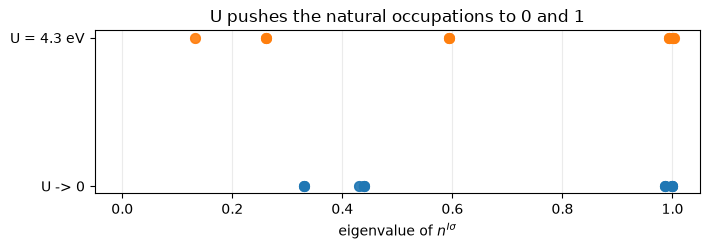

In [3]:
def occupations(result):
    ns = np.asarray(result.ns)
    return np.concatenate([np.linalg.eigvalsh(ns[s, slot])
                           for s in range(ns.shape[0])
                           for slot in range(ns.shape[1])])

fig, ax = plt.subplots(figsize=(7.2, 2.6))
for offset, (label, result) in enumerate((("U -> 0", no_u), ("U = 4.3 eV", scf))):
    values = occupations(result)
    ax.plot(values, np.full_like(values, offset), "o", ms=7, alpha=0.7,
            color=f"C{offset}")
    print("%-12s mean distance from the nearer of 0 and 1:  %.4f"
          % (label, np.minimum(values, 1.0 - values).mean()))
ax.set_yticks([0, 1])
ax.set_yticklabels(["U -> 0", "U = 4.3 eV"])
ax.set_xlim(-0.05, 1.05)
ax.grid(alpha=0.25, axis="x")
ax.set_xlabel(r"eigenvalue of $n^{I\sigma}$")
ax.set_title("U pushes the natural occupations to 0 and 1")
fig.tight_layout()

for label, result in (("U -> 0", no_u), ("U = 4.3 eV", scf)):
    traces = result.hubbard_occupations
    print("%-12s Tr[ns] up/down   %s"
          % (label, "   ".join("atom %d: %.4f / %.4f" % (atom + 1, t[0], t[1])
                               for atom, t in traces.items())))

## When one number is not enough

$U$ alone says how much it costs to put two electrons in the *same* shell. It
says nothing about which two, and inside a partly filled $d$ shell that is most
of the physics: Hund's rule is the statement that two electrons in different
orbitals with parallel spins cost less than two in different orbitals with
opposite spins. Writing that down means keeping the whole interaction rather
than its average,

$$E = \tfrac{1}{2} \sum_{\sigma\sigma'} \sum_{m_1 m_2 m_3 m_4}
      \Big[ v_{m_1 m_2 m_3 m_4} - \delta_{\sigma\sigma'} v_{m_1 m_2 m_4 m_3} \Big]
      n^{\sigma}_{m_1 m_3} n^{\sigma'}_{m_2 m_4} \; - \; E_{\mathrm{dc}},
\qquad
v_{m_1 m_2 m_3 m_4} = \sum_k F^k \, a^k_{m_1 m_3} \cdot a^k_{m_2 m_4}$$

with $a^k$ the angular integrals of three spherical harmonics. The radial part
is three numbers for a $d$ shell: $F^0$, which is $U$, and $F^2$ and $F^4$,
which between them are $J$. Adding a `J` to the card is what asks for it.

$E_{\mathrm{dc}}$ is the term that removes whatever the underlying functional
already counted, and there is more than one honest answer. The **fully
localised limit** assumes the shell holds a whole number of electrons, which is
right for a magnetic insulator and is what both functionals above use by
default. **Around mean field** assumes instead that the shell is uniformly
filled, so a shell that really is uniform gets no correction at all. The two
disagree most exactly where the correction matters, and which one to use is a
statement about the material.

In [4]:
full = Calculator.from_file(REFS / "feo-kind1-J.in", pseudo_dir=PSEUDO, conv_thr=1e-9)
amf = Calculator.from_file(REFS / "feo-amf.in", pseudo_dir=PSEUDO, conv_thr=1e-9)
fll_scf, amf_scf = full.get_scf(), amf.get_scf()

for label, result in (("fully localised", fll_scf), ("around mean field", amf_scf)):
    values = occupations(result)
    print("%-18s  E_U = %+8.4f Ry   spread of the shell = %.4f"
          % (label, result.energy_terms["hubbard"], values.std()))

fully localised     E_U =  +0.2321 Ry   spread of the shell = 0.3392
around mean field   E_U =  -0.0052 Ry   spread of the shell = 0.3057


Both runs are the same cell with the same $U = 4.3$ eV and $J = 1.0$ eV; only
the double counting differs. The fully localised limit charges the shell 0.23 Ry
and pulls its occupations apart; around mean field charges it almost nothing and
leaves them where the underlying functional put them. That is not a small
adjustment to the same answer, it is the difference between correcting a
localised electron and correcting an itinerant one.

## Where $U$ comes from

A published $U$ is usually fitted, and it is only meaningful together with the
projectors it was fitted for. The alternative is to compute the interaction from
the orbital itself: the shell's own radial function, integrated against a
screened Coulomb interaction whose range is the one free parameter,

$$F^k(\lambda) = \iint \mathrm{d}r\, \mathrm{d}r' \;
   [r\phi(r)]^2 \, [r'\phi(r')]^2 \;
   (2k+1)\, \lambda\, i_k(\lambda r_<)\, \tilde k_k(\lambda r_>)$$

which becomes the bare $r_<^k / r_>^{k+1}$ when the screening is switched off.
Screening is a long-ranged thing and $F^0$ is the long-ranged multipole, so it
is almost the only one that feels it.

nickel 3d, unscreened:  F0 = 23.44 eV   F2 = 11.06   F4 = 6.92   F4/F2 = 0.626   J = 1.28 eV
asking for U = 5.00 eV gives lambda = 2.096 bohr^-1,  and then J = 1.01 eV


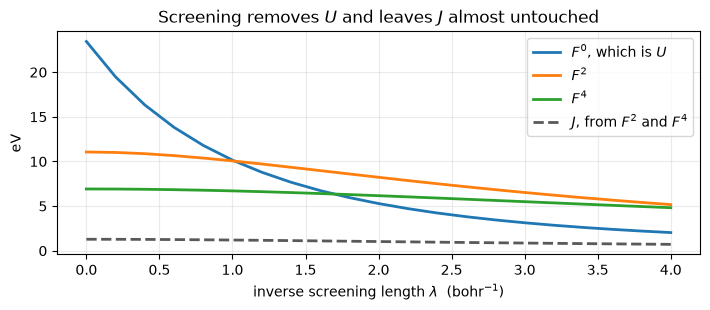

In [5]:
from defumat.hubbard import (  # no facade route: this is a property of a pseudopotential's orbital, not of a calculation
    exchange_from_slater, manifold_radial, screening_length, slater_set,
)
from defumat.pseudo import read_upf  # no facade route
from defumat.units import RY_TO_EV

nickel = manifold_radial(read_upf(PSEUDO / "Ni.rel-pbe-spn-kjpaw_psl.1.0.0.UPF"), 3, 2)
lambdas = np.linspace(0.0, 4.0, 21)
table = np.array([slater_set(nickel, 2, lam) for lam in lambdas])
hund = np.array([exchange_from_slater(2, f) for f in table]) * RY_TO_EV

fig, ax = plt.subplots(figsize=(7.2, 3.2))
for column, label in ((0, "$F^0$, which is $U$"), (2, "$F^2$"), (4, "$F^4$")):
    ax.plot(lambdas, table[:, column] * RY_TO_EV, "-", lw=2, label=label)
ax.plot(lambdas, hund, "--", lw=2, color="0.35", label="$J$, from $F^2$ and $F^4$")
ax.set_xlabel(r"inverse screening length $\lambda$  (bohr$^{-1}$)")
ax.set_ylabel("eV")
ax.set_title("Screening removes $U$ and leaves $J$ almost untouched")
ax.legend(); ax.grid(alpha=0.25)
fig.tight_layout()

print("nickel 3d, unscreened:  F0 = %.2f eV   F2 = %.2f   F4 = %.2f   F4/F2 = %.3f   J = %.2f eV"
      % (table[0, 0] * RY_TO_EV, table[0, 2] * RY_TO_EV, table[0, 4] * RY_TO_EV,
         table[0, 4] / table[0, 2], hund[0]))
lam = screening_length(nickel, 5.0 / RY_TO_EV)
chosen = slater_set(nickel, 2, lam)
print("asking for U = 5.00 eV gives lambda = %.3f bohr^-1,  and then J = %.2f eV"
      % (lam, exchange_from_slater(2, chosen) * RY_TO_EV))

The unscreened $F^4/F^2$ comes out at **0.626**, which is worth pausing on:
that ratio is a property of a $3d$ radial function and nothing else, and the
0.625 that codes normally *assume* is the value measured for free atoms. Here it
is computed from nickel's own orbital and agrees, so the assumption is a good one
for this shell and is now checkable rather than inherited. $J = 1.28$ eV is the
Hund coupling of a $3d$ shell, about the 1 eV that experiment and quantum
chemistry both give.

The dashed line is the practical point. Turning the screening up from nothing to
$\lambda = 3$ bohr$^{-1}$ takes $U$ from 23 eV down to 3, a factor of seven,
while $J$ falls only from 1.28 to 0.86. **$U$ and $J$ are not two dials on the
same knob**: the screening in a solid is what makes a bare 23 eV into a usable
4 or 5, and it barely touches the exchange. So a screened $U$ of 5 eV does not
imply a $J$ of 5/8 of an eV, which is the number the free-atom ratio would
suggest, and asking for that $U$ here returns $J = 1.01$ eV instead.

That is a measurement rather than an impression: **every** multiplet moves
closer to an integer, and the mean distance from the nearer of 0 and 1 falls
from 0.1998 to 0.1476. One of them crosses the midpoint to do it, going from
0.439 to 0.594, which is closer to 1 than 0.439 was to 0.

The two iron atoms carry opposite moments, which is what antiferromagnetic
means: atom 3 holds 4.99 of a possible 5 in its majority shell and 1.85 in its
minority, and atom 4 is its mirror image. Turning `U` on moved the majority from
4.9703 to 4.9911 and the minority from 1.9687 to 1.8454, both of them further
from a half-filled shell, which is the penalty doing exactly what it is written
to do.

## The projectors are part of the definition of `U`

An occupation is defined by a projection, so the number depends on what is
projected onto, and a published `U` is only meaningful together with the
projector set it was fitted for. Three are available. The projectors carry the
overlap operator, $S\varphi$ rather than $\varphi$, because that is what an
occupation is in a pseudopotential calculation. And the atomic orbitals of one
atom are not orthogonal to each other at a single k-point: nickel's `4s`
overlaps its `3d`, and `ortho-atomic` removes that by orthogonalising over every
atomic orbital in the cell, not just the ones carrying `U`. Nickel with
`ortho-atomic` projectors and $U = 3$ eV gives -85.628386898 Ry against `pw.x`'s
-85.628386900, measured the same way and quoted rather than re-run here.

## What it refuses

The intersite **V**, background channels, the orbital-resolved variant, the `wf`
and `pseudo` projector sets, and a Hubbard `U` on a **noncollinear** density.
Computing the interaction from the orbital needs a dataset that carries the
shell's all-electron radial function, which is what makes the integral above
mean anything; the others are refused by name rather than quietly done on a
function that is missing most of its weight.

---
The tests behind this notebook: `tests/regression/test_ldau.py` (nine cases
against Quantum ESPRESSO, and the Hubbard force),
`tests/regression/test_ldau_flavours.py` (the two flavours Quantum ESPRESSO does
not have, and the force under the full interaction),
`tests/unit/test_hubbard.py`, `tests/unit/test_hubbard_full.py` and
`tests/unit/test_hubbard_slater.py` (the potentials against closed forms, the
interaction matrix against a rotation, and the Slater integrals against a second
way of computing them).